In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [ ]:
x, y = make_circles(n_samples=750, factor=0.3, noise=0.1)
# n_samples is no. of data points
# factor controls the distance between the centers of the two circles
# noise Adds Gaussian noise to the data, making the classification task more challenging by slightly altering the positions of the points

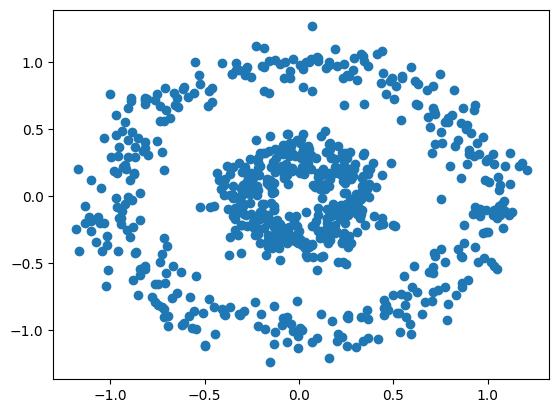

In [3]:
plt.scatter(x[:,0],x[:,1])

In [4]:
scaler = StandardScaler()
sc_x = scaler.fit_transform(x)

In [17]:
temp = DBSCAN(eps=0.1)
labels = temp.fit_predict(sc_x)

In [18]:
labels

array([ 0, -1,  1,  1,  0, -1,  2, -1, -1, -1, 12, -1, -1,  2, -1, -1, -1,
       -1,  0, -1, -1, -1, -1,  3, -1, -1, -1,  4, -1, -1, -1, -1, -1, -1,
        0,  5,  3,  4, -1, -1, -1,  1,  1, -1,  0,  0,  0, -1,  0,  5,  2,
        2,  4,  1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0, -1,  0,  6,  2,
       -1, -1, -1,  4,  0, -1,  0,  4,  0,  0, -1,  2, -1,  5,  2, -1, -1,
       -1,  4, -1, -1,  1,  0, -1,  1,  0,  2, -1, -1,  2,  0,  0,  2, -1,
        0, -1,  0, -1, -1,  3,  4, -1, -1,  0, -1, -1,  0,  7,  2,  2, 11,
        2, -1,  0,  0,  1,  0, -1, -1, -1, -1, -1,  4, -1,  0, -1,  2, -1,
        7, -1, -1,  0, -1,  2,  4,  4, -1,  4, -1, -1,  1,  1, -1, -1,  2,
        0, -1,  0, -1, -1, -1,  0, -1, -1,  6,  2, -1, 14, -1, -1, -1,  9,
       -1, -1, -1,  9,  0, -1, -1,  2,  2,  2,  4, -1,  0,  1, -1,  2, -1,
        0, -1, -1, 17, -1,  5,  0,  2, -1, 10, -1,  1,  0, 12,  2, -1, -1,
        8, -1, -1,  0,  0, 10, -1, -1, -1, -1, -1, -1, -1,  1, -1,  2, -1,
        0, -1, -1,  0,  0

In [19]:
outlier_mask = labels == -1
core_mask = labels != -1

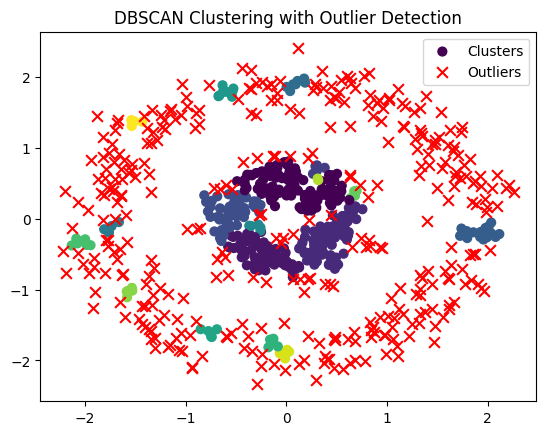

In [20]:
plt.scatter(sc_x[core_mask, 0], sc_x[core_mask, 1], c=labels[core_mask], cmap='viridis', s=40, label='Clusters')
plt.scatter(sc_x[outlier_mask, 0], sc_x[outlier_mask, 1], c='red', marker='x', s=60, label='Outliers')
plt.title('DBSCAN Clustering with Outlier Detection')
plt.legend()
plt.show()

In [39]:
# select best eps value
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.linspace(0.1, 2.0, 20)
best_score = -1
best_eps = None

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=4)
    clusters = db.fit_predict(sc_x)
    
    if len(set(clusters)) > 1:  
        score = silhouette_score(sc_x, clusters)
        if score > best_score:
            best_score = score
            best_eps = eps

print(f'Best eps: {best_eps}')


Best eps: 0.2


In [37]:
# for make_moons dataset
p, q = make_moons(n_samples=750, noise=0.1) 

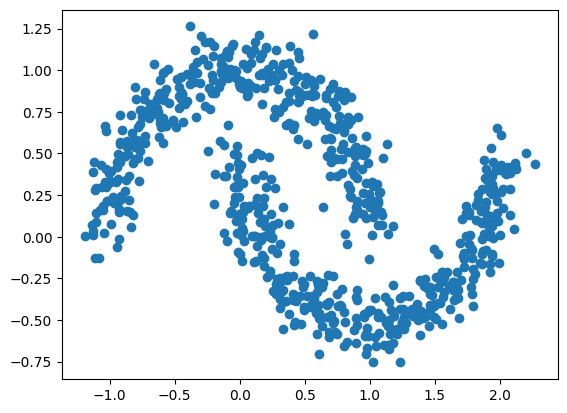

In [31]:
plt.scatter(p[:,0],p[:,1])

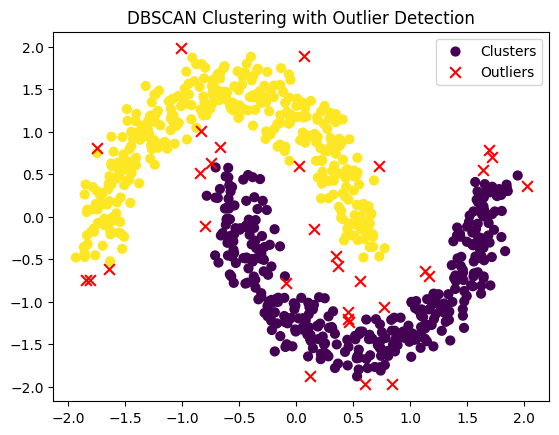

In [35]:
scaler = StandardScaler()
sc_p = scaler.fit_transform(p)
temp2 = DBSCAN(eps=0.15)
labels2 = temp2.fit_predict(sc_p)
labels2
outlier_mask2 = labels2 == -1
core_mask2 = labels2 != -1
plt.scatter(sc_p[core_mask2, 0], sc_p[core_mask2, 1], c=labels2[core_mask2], cmap='viridis', s=40, label='Clusters')
plt.scatter(sc_p[outlier_mask2, 0], sc_p[outlier_mask2, 1], c='red', marker='x', s=60, label='Outliers')
plt.title('DBSCAN Clustering with Outlier Detection')
plt.legend()
plt.show()